In [ ]:
! pip install opencxr

  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opencxr to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 36.0 MB/s eta 0:00:00
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=476e4e443d4bd3457d387ae8f916b95d73dd919554561b4950ac0d638e6b103a
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


### Muntatge de Google Drive a Colab
Aquest codi connecta el Google Drive amb Google Colab, creant la carpeta:

`/content/drive`




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Definició de rutes del dataset NODE21
Aquest fragment configura les rutes base del dataset:

- `BASE_PATH`: carpeta principal del dataset (en aquest cas s’està usant **original_data**).
- `PATH_IMAGES`: ruta on es troben les imatges (`/images`).
- `PATH_METADATA`: fitxer CSV amb les anotacions i etiquetes (`metadata.csv`).

Finalment, es mostren per pantalla les rutes per comprovar que són correctes.


In [ ]:
BASE_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data"
BASE_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/original_data"

PATH_IMAGES = f"{BASE_PATH}/images"
PATH_METADATA = f"{BASE_PATH}/metadata.csv"
#PATH_METADATA = "/content/drive/MyDrive/ML/DATASETS/NODE21/metadata_balanced.csv"

print(PATH_IMAGES)
print(PATH_METADATA)

/content/drive/MyDrive/ML/DATASETS/NODE21/original_data/images
/content/drive/MyDrive/ML/DATASETS/NODE21/original_data/metadata.csv


### Càrrega del metadata i creació de la ruta completa de cada imatge
Aquest codi llegeix el fitxer `metadata.csv` amb **pandas** i construeix una nova columna `file_path` amb la ruta completa cap a cada imatge, combinant `PATH_IMAGES` i `img_name`.

Després:
- mostra les primeres files del DataFrame (`df.head()`),
- i calcula quantes mostres són **negatives** (`label = 0`) i quantes són **positives** (`label = 1`).


In [ ]:
import pandas as pd
import os

df = pd.read_csv(PATH_METADATA)

df["file_path"] = df["img_name"].apply(
    lambda x: os.path.join(PATH_IMAGES, x)
)

df.head()

num_neg = (df["label"] == 0).sum()
num_pos = (df["label"] == 1).sum()

print("Negativos:", num_neg)
print("Positivos:", num_pos)



Negativos: 3748
Positivos: 1476


In [ ]:
!ls "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data"

images	metadata.csv  simulated_metadata.csv


### Visualització d’una imatge `.mha` amb OpenCXR
Aquest fragment selecciona una imatge del dataset (`df["file_path"].iloc[1001]`), la carrega amb `read_file()` d’OpenCXR i la mostra amb **matplotlib** en escala de grisos.

A més, `read_file()` també retorna informació del **spacing** (resolució física del píxel), tot i que aquí només s’utilitza per carregar la imatge.


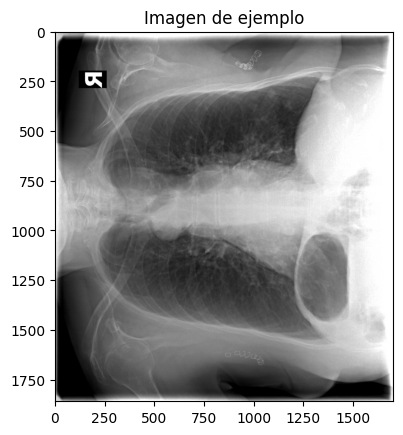

In [ ]:
from opencxr.utils.file_io import read_file, write_file
import matplotlib.pyplot as plt

sample_path = df["file_path"].iloc[1001]
img_np, spacing, _ = read_file(sample_path)

plt.imshow(img_np, cmap="gray")
plt.title("Imagen de ejemplo")
plt.axis("on")
plt.show()

### Pipeline complet de classificació multicanal (NODE21)

Aquest codi prepara un **pipeline end-to-end** per entrenar i avaluar un model de **classificació binària** (nòdul vs no nòdul) amb imatges **CXR** en format `.mha`.

Inclou: càrrega de dades, generació de **3 canals**, augmentació, `DataLoader`, entrenament i avaluació.

---

### 1) Imports i device
Carrega totes les llibreries necessàries (PyTorch, CV2, pandas, sklearn, OpenCXR...) i defineix si s’executa en **GPU (cuda)** o **CPU**.

---

### 2) Rutes i càrrega del CSV
Llegeix el `metadata_balanced.csv`, compta positius/negatius i filtra només les files que tenen el fitxer físic existent (`file_path` vàlid).  
Això evita errors per imatges inexistents.

---

### 3) Augmentació de dades
La funció `augment_image()` aplica augmentació **simple i ràpida** sobre un tensor `(3,H,W)`:

- *Flip* horitzontal
- Rotació suau
- Soroll gaussià

---

### 4) Dataset multicanal
`CXRClassificationDataset`:

- Carrega la imatge `.mha` amb `read_file()`
- Normalitza a `[0,1]`
- Fa `resize` a `224×224`
- Construeix 3 canals:
  1. **Original**
  2. **CLAHE**
  3. **Canny edges**
- Retorna `image` i `label` com tensors PyTorch

Inclou una protecció `error=True` si falla la lectura.

---

### 5) Collate personalitzat
`custom_collate()` elimina exemples incorrectes (`error=True`) i crea batches finals:

- `images`: tensor `[B,3,224,224]`
- `labels`: tensor `[B]`

---

### 6) Split train/test + DataLoaders
Divideix el dataset en:

- `train_df` (80%) amb augmentació
- `test_df` (20%) sense augmentació

I crea els `DataLoader` amb `batch_size=32`.

---

### 7) Visualització dels canals
Mostra els **3 canals** generats d’una imatge del primer batch, per comprovar que el preprocessat és correcte.

---

### 8) Entrenament universal
`train_model()` entrena qualsevol model compatible amb:

- `CrossEntropyLoss`
- `Adam(lr=1e-3)`

Calcula loss i accuracy per epoch.

---

### 9) Avaluació
`evaluate_model()` fa inferència sobre el `test_loader` i mostra:

- `classification_report`
- `confusion_matrix`

És una validació bàsica per veure rendiment global del model.


Device: cuda
Negativos: 3748
Positivos: 3748
Total imágenes válidas: 7496


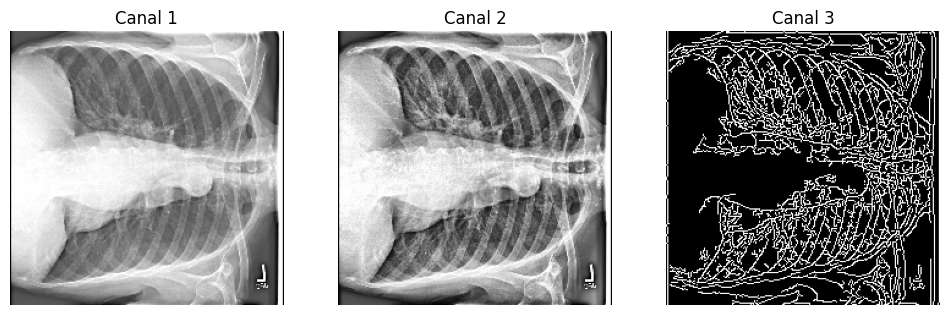

In [ ]:
# ============================================================
# 1. IMPORTS
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import cv2
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from opencxr.utils.file_io import read_file

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ============================================================
# 2. RUTES
# ============================================================
BASE_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data"

PATH_IMAGES = f"{BASE_PATH}/images"
PATH_METADATA = f"{BASE_PATH}/metadata.csv"
PATH_METADATA = "/content/drive/MyDrive/ML/DATASETS/NODE21/metadata_balanced.csv"

df = pd.read_csv(PATH_METADATA)

num_neg = (df["label"] == 0).sum()
num_pos = (df["label"] == 1).sum()
print("Negativos:", num_neg)
print("Positivos:", num_pos)
#df["file_path"] = df["img_name"].apply(lambda x: os.path.join(PATH_IMAGES, x))
#df = df[df["file_path"].apply(os.path.exists)].reset_index(drop=True)
# Verificar qué imágenes existen físicamente
df = df[df["file_path"].apply(os.path.exists)].reset_index(drop=True)
print("Total imágenes válidas:", len(df))


# ============================================================
# 3. DATA AUGMENTATION
# ============================================================
def augment_image(img3):
    # img3: numpy array (3,H,W)

    C, H, W = img3.shape

    # Flip horizontal
    if np.random.rand() < 0.5:
        img3 = img3[:, :, ::-1].copy()

    # Rotación suave
    if np.random.rand() < 0.5:
        angle = np.random.uniform(-7, 7)
        M = cv2.getRotationMatrix2D((W/2, H/2), angle, 1.0)

        rotated = []
        for c in range(C):
            rc = cv2.warpAffine(img3[c], M, (W, H),
                                flags=cv2.INTER_LINEAR,
                                borderMode=cv2.BORDER_REFLECT_101)
            rotated.append(rc)
        img3 = np.stack(rotated, axis=0)

    # Ruido gaussiano
    if np.random.rand() < 0.3:
        noise = np.random.normal(0.0, 0.03, img3.shape)
        img3 = np.clip(img3 + noise, 0.0, 1.0)

    return img3.copy()


# ============================================================
# 4. DATASET MULTICANAL
# ============================================================
class CXRClassificationDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]
        path = row["file_path"]

        try:
            img_np, _, _ = read_file(path)  
        except:
            return {"error": True}

        # Normalizar a [0,1]
        img = img_np.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # Resize
        img = cv2.resize(img, (224, 224))

        # -------------------------------------------------------------
        # CANAL 1 ORIGINAL
        # CANAL 2 CLAHE
        # CANAL 3 BORDES CANNY
        # -------------------------------------------------------------
        img_255 = (img * 255).astype(np.uint8)

        # Canal 1
        ch1 = img

        # Canal 2: CLAHE
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        ch2 = clahe.apply(img_255).astype(np.float32) / 255.0

        # Canal 3: Canny
        ch3 = cv2.Canny(img_255, 50, 150).astype(np.float32) / 255.0

        img3 = np.stack([ch1, ch2, ch3], axis=0)

        # Augmentació
        if self.augment:
            img3 = augment_image(img3)

        img3 = img3.copy()

        return {
            "error": False,
            "image": torch.tensor(img3, dtype=torch.float32),
            "label": torch.tensor(row["label"], dtype=torch.long)
        }


# ============================================================
# 5. COLLATE
# ============================================================
def custom_collate(batch):
    batch = [b for b in batch if b is not None and not b["error"]]
    if len(batch) == 0:
        return None
    images = torch.stack([b["image"] for b in batch])
    labels = torch.stack([b["label"] for b in batch])
    return images, labels


# ============================================================
# 6. SPLIT TRAIN/TEST EN MULTICANAL
# ============================================================
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_dataset = CXRClassificationDataset(train_df, augment=True)
test_dataset  = CXRClassificationDataset(test_df, augment=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, pin_memory=True, collate_fn=custom_collate)

test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False,
                          num_workers=2, pin_memory=True, collate_fn=custom_collate)


# ============================================================
# 7. VISUALITZACIÓ DELS CANALS
# ============================================================
batch = next(iter(train_loader))
imgs, labels = batch

plt.figure(figsize=(12,4))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(imgs[0,i].cpu(), cmap="gray")
    plt.title(f"Canal {i+1}")
    plt.axis("off")
plt.show()


# ============================================================
# 8. ENTRENAMENT UNIVERSAL
# ============================================================
def train_model(model, train_loader, test_loader=None, epochs=5):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        model.train()

        running_loss = 0
        correct = 0
        total = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for batch in loop:
            if batch is None:
                continue

            images, labels = batch
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

            loop.set_postfix(loss=loss.item())

        print(f"Epoch {epoch+1}: Loss={running_loss/len(train_loader):.4f}  Acc={correct/total:.4f}")

    return model


# ============================================================
# 9. EVALUACIÓ
# ============================================================
def evaluate_model(model, loader):

    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for batch in loader:
            if batch is None:
                continue

            images, labels = batch
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    print("\n=== Classification Report ===")
    print(classification_report(all_labels, all_preds, digits=4))

    print("\n=== Confusion Matrix ===")
    print(confusion_matrix(all_labels, all_preds))


In [ ]:
num_neg = (df["label"] == 0).sum()
num_pos = (df["label"] == 1).sum()

print("Negativos:", num_neg)
print("Positivos:", num_pos)


Negativos: 3748
Positivos: 3748


Lo mismo pero con el data augmentation no se ha de volver a lanzar que ya tenemos data augmentatiom

### Càrrega i preparació de dades (original_data)
Carrega el CSV `metadata.csv`, construeix el `file_path` cap a les imatges `.mha` originals i prepara el dataset per treballar des de la ruta del Drive.

---

### Augmentació mèdica avançada (positius)
`augment_medical()` aplica transformacions “realistes” sobre una imatge CXR (soroll, blur, gamma, brillantor, contrast, sharpen, CLAHE i lleu distorsió) per generar variabilitat clínica.

---

### Balanceig automàtic amb augmentació
`balance_with_augmentation()` iguala el nombre de positius amb els negatius:
- calcula quants positius falten
- genera imatges augmentades només de casos positius
- guarda els nous fitxers i crea noves files de metadata

---

### Generació del nou metadata balancejat
Crea `metadata_original_balanced.csv` amb la distribució final equilibrada i filtra només els fitxers que existeixen realment.

---

### Dataset de classificació generalitzat (2 modes)
`CXRClassificationDataset` llegeix la imatge `.mha`, normalitza, fa resize a `224×224` i crea 3 canals segons mode:

- **replicate**: 3 canals iguals (grayscale repetit)
- **multicanal**: `original + CLAHE + Canny`

Opcionalment aplica augmentació extra (`augment_image`) en entrenament.

---

### DataLoaders + split train/test
Divideix el dataset (80/20) i crea `DataLoader` amb batchs, col·late robust i multicanal activat.

---

### Visualització de canals
Mostra els 3 canals d’una imatge del primer batch per comprovar que el preprocessat multicanal és correcte.

---

### Entrenament universal
`train_model()` entrena el model amb `CrossEntropyLoss` i `Adam`, mostrant loss i accuracy per epoch.

---

### Avaluació universal
`evaluate_model()` calcula el `classification_report` i la `confusion_matrix` sobre el test set.


Device: cuda
/content/drive/MyDrive/ML/DATASETS/NODE21/original_data/images1
/content/drive/MyDrive/ML/DATASETS/NODE21/original_data/metadata.csv
Positivos: 1476 | Negativos: 3748
Positivos deseados: 3748
Generando 2272 imágenes augmentadas...


100%|██████████| 2272/2272 [45:28<00:00,  1.20s/it]


Augmentación completada.

Distribución final:
label
0    3748
1    3748
Name: count, dtype: int64
Total imágenes válidas: 5224
4179 1045


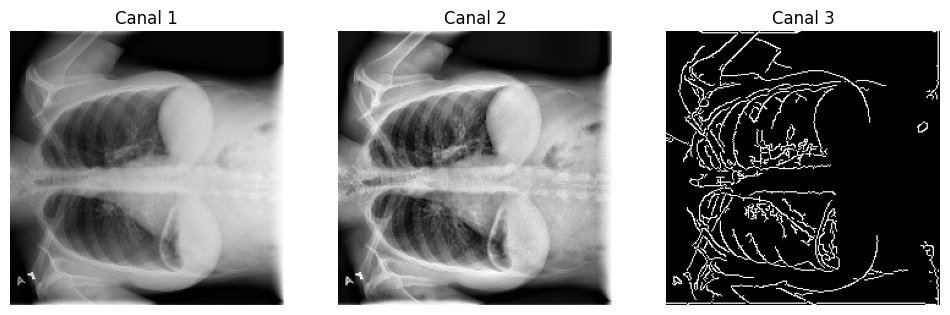

In [ ]:
# ============================================================
# 1. IMPORTS
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import cv2
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from opencxr.utils.file_io import read_file


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ============================================================
# 2. RUTAS DEL DATASET
# ============================================================
#BASE_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data"
BASE_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/original_data"

PATH_IMAGES = f"{BASE_PATH}/images1"
PATH_METADATA = f"{BASE_PATH}/metadata.csv"
print(PATH_IMAGES)
print(PATH_METADATA)


# ============================================================
# 3. CARGA DEL METADATA
# ============================================================
df = pd.read_csv(PATH_METADATA)
df["file_path"] = df["img_name"].apply(
    lambda x: os.path.join(PATH_IMAGES, x)
)
# ============================================================
# 4. AUGMENTACIÓN MÉDICA AVANZADA
# ============================================================

def augment_medical(img):
 
    H, W = img.shape
    img_aug = img.copy()

    # 1. Flip horizontal
    #if np.random.rand() < 0.5:
    #    img_aug = img_aug[:, ::-1]

    # 2. Rotación suave
    #if np.random.rand() < 0.5:
    #    angle = np.random.uniform(-8, 8)
    #    M = cv2.getRotationMatrix2D((W/2, H/2), angle, 1.0)
    #    img_aug = cv2.warpAffine(img_aug, M, (W, H), borderMode=cv2.BORDER_REFLECT_101)

    # 3. Ruido gaussiano
    if np.random.rand() < 0.4:
        noise = np.random.normal(0.0, 0.03, img_aug.shape)
        img_aug = np.clip(img_aug + noise, 0, 1)

    # 4. Blur gaussiano
    if np.random.rand() < 0.3:
        img_aug = cv2.GaussianBlur(img_aug, (3,3), 0)

    # 5. Gamma correction
    if np.random.rand() < 0.3:
        gamma = np.random.uniform(0.8, 1.2)
        img_aug = np.power(img_aug, gamma)

    # 6. Brillo
    if np.random.rand() < 0.3:
        delta = np.random.uniform(-0.1, 0.1)
        img_aug = np.clip(img_aug + delta, 0, 1)

    # 7. Contraste
    if np.random.rand() < 0.3:
        alpha = np.random.uniform(0.9, 1.1)
        img_aug = np.clip(img_aug * alpha, 0, 1)

    # 8. Sharpen
    if np.random.rand() < 0.2:
        kernel = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])
        img_aug = cv2.filter2D(img_aug, -1, kernel)
        img_aug = np.clip(img_aug, 0, 1)

    # 9. CLAHE adicional
    if np.random.rand() < 0.3:
        clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8,8))
        img_aug = clahe.apply((img_aug*255).astype(np.uint8)).astype(np.float32)/255.0

    # 10. Distorsión leve
    if np.random.rand() < 0.2:
        pts1 = np.float32([[0,0],[W,0],[0,H]])
        pts2 = pts1 + np.random.uniform(-3,3,size=(3,2)).astype(np.float32)
        M = cv2.getAffineTransform(pts1, pts2)
        img_aug = cv2.warpAffine(img_aug, M, (W, H), borderMode=cv2.BORDER_REFLECT_101)

    return img_aug


# ============================================================
# 5. FUNCIÓN PARA BALANCEAR EL DATASET
# ============================================================

def balance_with_augmentation(df, output_path, target_count=None):
    os.makedirs(output_path, exist_ok=True)

    df_pos = df[df["label"] == 1].copy()
    df_neg = df[df["label"] == 0].copy()

    pos_count = len(df_pos)
    neg_count = len(df_neg)

    if target_count is None:
        target_count = neg_count

    print(f"Positivos: {pos_count} | Negativos: {neg_count}")
    print(f"Positivos deseados: {target_count}")

    if pos_count >= target_count:
        print("No es necesario augmentar.")
        return df.copy()

    to_generate = target_count - pos_count
    print(f"Generando {to_generate} imágenes augmentadas...")

    new_rows = []
    pos_rows = df_pos.to_dict("records")
    idx = 0

    for i in tqdm(range(to_generate)):
        row = pos_rows[idx]
        idx = (idx + 1) % len(pos_rows)

        img_path = row["file_path"]
        img_np, spacing, _ = read_file(img_path)

        img = img_np.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        img = cv2.resize(img, (224,224))

        img_aug = augment_medical(img)

        new_name = f"aug_pos_{i}.mha"
        new_path = os.path.join(output_path, new_name)
        write_file(new_path, img_aug.astype(np.float32), spacing)

        new_rows.append({
            "img_name": new_name,
            "file_path": new_path,
            "label": 1
        })

    print("Augmentación completada.")
    df_new = pd.concat([df_neg, df_pos, pd.DataFrame(new_rows)], ignore_index=True)
    print("\nDistribución final:")
    print(df_new["label"].value_counts())

    return df_new
# ============================================================
# 6. GENERAR DATASET BALANCEADO
# ============================================================

#output_aug_dir = "/content/drive/MyDrive/ML/DATASETS/NODE21/augmented_pos"
output_aug_dir = "/content/drive/MyDrive/ML/DATASETS/NODE21/original_augmented_pos"

df_balanced = balance_with_augmentation(
    df=df,
    output_path=output_aug_dir,
    target_count=None   # None = igualar positius als negatius
)

# Guardar nou metadata
#df_balanced.to_csv("/content/drive/MyDrive/ML/DATASETS/NODE21/metadata_balanced.csv", index=False)
df_balanced.to_csv("/content/drive/MyDrive/ML/DATASETS/NODE21/metadata_original_balanced.csv", index=False)


#PATH_METADATA = "/content/drive/MyDrive/ML/DATASETS/NODE21/metadata_balanced.csv"
PATH_METADATA = "/content/drive/MyDrive/ML/DATASETS/NODE21/metadata_original_balanced.csv"
df = pd.read_csv(PATH_METADATA)




df["file_path"] = df["img_name"].apply(lambda x: os.path.join(PATH_IMAGES, x))
df = df[df["file_path"].apply(os.path.exists)].reset_index(drop=True)
#--------------------
print("Total imágenes válidas:", len(df))
df.head()


# ============================================================
# 4. DATA AUGMENTATION
# ============================================================
def augment_image(img):
    # img: numpy array (3,H,W)
    C, H, W = img.shape

    # 1) Flip horizontal
    #if np.random.rand() < 0.5:
    #    img = img[:, :, ::-1].copy()

    # 2) Rotación suave
    #if np.random.rand() < 0.5:
    #    angle = np.random.uniform(-7, 7)
    #    M = cv2.getRotationMatrix2D((W/2, H/2), angle, 1.0)

    #    rotated = []
    #    for c in range(C):
    #        rc = cv2.warpAffine(img[c], M, (W, H),
    #                            flags=cv2.INTER_LINEAR,
    #                            borderMode=cv2.BORDER_REFLECT_101)
    #        rotated.append(rc)
    #    img = np.stack(rotated, axis=0)

    # 3) Ruido gaussiano
    if np.random.rand() < 0.3:
        noise = np.random.normal(0.0, 0.03, img.shape)
        img = np.clip(img + noise, 0.0, 1.0)

    return img.copy()


# ============================================================
# 5. DATASET GENERALIZADO
# ============================================================
class CXRClassificationDataset(Dataset):
    def __init__(self, df, augment=False, mode="replicate"):
        """
        mode:
          - "replicate": 3 canales idénticos
          - "multicanal": original + CLAHE + bordes Canny
        """
        self.df = df[df["file_path"].apply(os.path.exists)].reset_index(drop=True)
        self.augment = augment
        self.mode = mode

    def __len__(self):
        return len(self.df)

    def _build_channels(self, img):
        """
        img: (H,W) normalizada [0,1]
        devuelve (3,H,W)
        """
        if self.mode == "replicate":
            return np.repeat(np.expand_dims(img, axis=0), 3, axis=0).copy()

        elif self.mode == "multicanal":
            img_255 = (img * 255).astype(np.uint8)

            # Canal 1 original
            ch1 = img

            # Canal 2 CLAHE
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            ch2 = clahe.apply(img_255).astype(np.float32) / 255.0

            # Canal 3 bordes
            ch3 = cv2.Canny(img_255, 50, 150).astype(np.float32) / 255.0

            return np.stack([ch1, ch2, ch3], axis=0).copy()

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["file_path"]

        try:
            img_np, _, _ = read_file(path)
        except:
            return {"error": True}

        # Normalizar
        img = img_np.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # Resize
        img = cv2.resize(img, (224, 224))

        # Construir canales
        img3 = self._build_channels(img)

        # Augmentation si corresponde
        if self.augment:
            img3 = augment_image(img3)

        img3 = img3.copy()

        return {
            "error": False,
            "image": torch.tensor(img3, dtype=torch.float32),
            "label": torch.tensor(row["label"], dtype=torch.long)
        }


# ============================================================
# 6. COLLATE
# ============================================================
def custom_collate(batch):
    batch = [b for b in batch if b is not None and not b["error"]]
    if len(batch) == 0:
        return None
    images = torch.stack([b["image"] for b in batch])
    labels = torch.stack([b["label"] for b in batch])
    return images, labels


# ============================================================
# 7. SPLIT + DATALOADERS
# ============================================================
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)


train_dataset = CXRClassificationDataset(train_df, augment=True,  mode="multicanal")
test_dataset  = CXRClassificationDataset(test_df,  augment=False, mode="multicanal")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, pin_memory=True, collate_fn=custom_collate)

test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False,
                          num_workers=2, pin_memory=True, collate_fn=custom_collate)

print(len(train_dataset), len(test_dataset))


# ============================================================
# 8. VISUALIZACIÓN DE CANALES
# ============================================================
batch = next(iter(train_loader))
imgs, labels = batch

plt.figure(figsize=(12,4))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(imgs[0,i].cpu(), cmap="gray")
    plt.title(f"Canal {i+1}")
    plt.axis("off")
plt.show()


# ============================================================
# 9. FUNCIÓN DE ENTRENAMIENTO UNIVERSAL
# ============================================================
def train_model(model, train_loader, test_loader, epochs=5):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for batch in loop:
            if batch is None:
                continue

            images, labels = batch
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

            loop.set_postfix(loss=loss.item())

        print(f"Epoch {epoch+1}: Loss={running_loss/len(train_loader):.4f}  Acc={correct/total:.4f}")

    return model


# ============================================================
# 10. EVALUACIÓN UNIVERSAL
# ============================================================
def evaluate_model(model, test_loader):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for batch in test_loader:
            if batch is None:
                continue

            images, labels = batch
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    print("\n=== Classification Report ===")
    print(classification_report(all_labels, all_preds, digits=4))

    print("\n=== Confusion Matrix ===")
    print(confusion_matrix(all_labels, all_preds))


### Model EfficientNet-B0 adaptat a 2 classes
Carrega **EfficientNet-B0 preentrenada en ImageNet**, substitueix l’última capa `Linear` per sortir amb **2 classes** (negatiu / positiu) i envia el model a GPU/CPU.

---

### Entrenament del model
Entrena el model amb el `train_loader` durant **5 epochs** utilitzant la funció `train_model()`.

---

### Avaluació final
Executa `evaluate_model()` sobre el `test_loader` per obtenir el **classification report** i la **matriu de confusió**.


In [ ]:
from torchvision import models

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
n = model.classifier[1].in_features
model.classifier[1] = nn.Linear(n, 2)
model = model.to(device)

model = train_model(model, train_loader, test_loader, epochs=5)
evaluate_model(model, test_loader)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 122MB/s]
Epoch 1/5: 100%|██████████| 131/131 [43:11<00:00, 19.78s/it, loss=0.252]


Epoch 1: Loss=0.3372  Acc=0.8512


Epoch 2/5: 100%|██████████| 131/131 [02:00<00:00,  1.09it/s, loss=0.402]


Epoch 2: Loss=0.1909  Acc=0.9244


...

Epoch 4/5: 100%|██████████| 131/131 [01:57<00:00,  1.11it/s, loss=0.0916]


Epoch 4: Loss=0.1108  Acc=0.9579


Epoch 5/5: 100%|██████████| 131/131 [01:59<00:00,  1.10it/s, loss=0.0638]

Epoch 5: Loss=0.1039  Acc=0.9605



=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9392    0.9918    0.9648       732
           1     0.9779    0.8498    0.9094       313

    accuracy                         0.9493      1045
   macro avg     0.9586    0.9208    0.9371      1045
weighted avg     0.9508    0.9493    0.9482      1045


=== Confusion Matrix ===
[[726   6]
 [ 47 266]]


### Model DenseNet169 adaptat a 2 classes
Carrega **DenseNet169 preentrenada en ImageNet**, reemplaça la capa final `classifier` per una `Linear` amb sortida de **2 classes** (negatiu / positiu), i envia el model a GPU/CPU.

---

### Entrenament del model
Entrena el model amb el `train_loader` durant **5 epochs** amb la funció `train_model()`.

---

### Avaluació final
Avalua el rendiment amb `evaluate_model()` sobre el `test_loader`, mostrant el **classification report** i la **matriu de confusió**.


In [ ]:
from torchvision import models

model = models.densenet169(weights=models.DenseNet169_Weights.IMAGENET1K_V1)
n = model.classifier.in_features
model.classifier = nn.Linear(n, 2)
model = model.to(device)

model = train_model(model, train_loader, test_loader, epochs=5)
evaluate_model(model, test_loader)

Epoch 1/5: 100%|██████████| 131/131 [02:00<00:00,  1.08it/s, loss=0.154]


Epoch 1: Loss=0.3493  Acc=0.8425


Epoch 2/5: 100%|██████████| 131/131 [02:00<00:00,  1.09it/s, loss=0.258]


Epoch 2: Loss=0.1995  Acc=0.9227


Epoch 3/5: 100%|██████████| 131/131 [02:01<00:00,  1.08it/s, loss=0.259]


...

Epoch 4/5: 100%|██████████| 131/131 [02:01<00:00,  1.08it/s, loss=0.0816]


Epoch 4: Loss=0.1533  Acc=0.9392


Epoch 5/5: 100%|██████████| 131/131 [02:00<00:00,  1.09it/s, loss=0.0337]

Epoch 5: Loss=0.1510  Acc=0.9440



=== Classification Report ===
              precision    recall  f1-score   support

           0     0.8983    0.9891    0.9415       732
           1     0.9665    0.7380    0.8370       313

    accuracy                         0.9139      1045
   macro avg     0.9324    0.8635    0.8892      1045
weighted avg     0.9187    0.9139    0.9102      1045


=== Confusion Matrix ===
[[724   8]
 [ 82 231]]


### Fine-tuning d’EfficientNet-B0 per classificació binària
Es carrega **EfficientNet-B0 preentrenada en ImageNet**, es substitueix la capa final (`classifier[1]`) per una capa `Linear(n, 2)` per predir **2 classes** (negatiu/positiu) i es mou el model al **device** (CPU/GPU).

---

### Entrenament
S’entrena el model durant **5 epochs** amb `train_model()` utilitzant `train_loader`.

---

### Avaluació
S’avalua el model amb `evaluate_model()` sobre `test_loader`, obtenint el **classification report** i la **confusion matrix**.


In [ ]:
from torchvision import models

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
n = model.classifier[1].in_features
model.classifier[1] = nn.Linear(n, 2)
model = model.to(device)

model = train_model(model, train_loader, test_loader, epochs=5)
evaluate_model(model, test_loader)

Epoch 1/5: 100%|██████████| 131/131 [01:59<00:00,  1.09it/s, loss=0.209]


Epoch 1: Loss=0.3335  Acc=0.8500


Epoch 2/5: 100%|██████████| 131/131 [02:00<00:00,  1.09it/s, loss=0.0742]


Epoch 2: Loss=0.1827  Acc=0.9292


Epoch 3/5: 100%|██████████| 131/131 [02:01<00:00,  1.08it/s, loss=0.202]


...

Epoch 4/5: 100%|██████████| 131/131 [02:01<00:00,  1.08it/s, loss=0.0382]


Epoch 4: Loss=0.1140  Acc=0.9610


Epoch 5/5: 100%|██████████| 131/131 [01:59<00:00,  1.10it/s, loss=0.0169]

Epoch 5: Loss=0.1057  Acc=0.9596



=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9875    0.9699    0.9786       732
           1     0.9325    0.9712    0.9515       313

    accuracy                         0.9703      1045
   macro avg     0.9600    0.9706    0.9651      1045
weighted avg     0.9710    0.9703    0.9705      1045


=== Confusion Matrix ===
[[710  22]
 [  9 304]]


### Entrenament i avaluació d’EfficientNet-B0 (ImageNet NODE21)
Es carrega **EfficientNet-B0 preentrenada en ImageNet**, s’adapta la capa final (`classifier[1]`) per predir **2 classes**, i s’entrena durant **5 epochs** amb el `train_loader`.

Després, s’avalua el model amb `test_loader` i es generen el **classification report** i la **confusion matrix** per mesurar el rendiment.


In [ ]:
from torchvision import models

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
n = model.classifier[1].in_features
model.classifier[1] = nn.Linear(n, 2)
model = model.to(device)

model = train_model(model, train_loader, test_loader, epochs=5)
evaluate_model(model, test_loader)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 220MB/s]
Epoch 1/5: 100%|██████████| 188/188 [41:44<00:00, 13.32s/it, loss=0.303]


Epoch 1: Loss=0.3502  Acc=0.8467


Epoch 2/5: 100%|██████████| 188/188 [02:32<00:00,  1.23it/s, loss=0.0382]


Epoch 2: Loss=0.1936  Acc=0.9251


...

Epoch 4/5: 100%|██████████| 188/188 [02:33<00:00,  1.23it/s, loss=0.104]


Epoch 4: Loss=0.1089  Acc=0.9613


Epoch 5/5: 100%|██████████| 188/188 [02:33<00:00,  1.23it/s, loss=0.0416]

Epoch 5: Loss=0.1146  Acc=0.9568



=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9289    0.9920    0.9594       751
           1     0.9914    0.9239    0.9565       749

    accuracy                         0.9580      1500
   macro avg     0.9602    0.9580    0.9579      1500
weighted avg     0.9601    0.9580    0.9579      1500


=== Confusion Matrix ===
[[745   6]
 [ 57 692]]


### Fine-tuning d’EfficientNet-B0 per classificació binària (NODE21)
Es carrega **EfficientNet-B0 preentrenada en ImageNet**, i es substitueix la capa final (`classifier[1]`) per una nova capa `Linear` amb **2 sortides** (negatiu / positiu).

A continuació, el model s’entrena durant **5 epochs** amb `train_loader`, i finalment s’avalua amb `test_loader` generant el **classification report** i la **confusion matrix**.


In [ ]:
from torchvision import models

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
n = model.classifier[1].in_features
model.classifier[1] = nn.Linear(n, 2)
model = model.to(device)

model = train_model(model, train_loader, test_loader, epochs=5)
evaluate_model(model, test_loader)

### Guardar el model entrenat (checkpoint)
Aquest codi guarda els **pesos entrenats** del model (`state_dict`) en un fitxer `.pth` dins Google Drive.

Així després podràs **recarregar el model** i continuar entrenant o fer inferència sense haver de reentrenar des de zero.


In [ ]:
# === GUARDAR MODEL ===
MODEL_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/efficientnet_b0_multicanal.pth"
torch.save(model.state_dict(), MODEL_PATH)

print("Model guardat a:", MODEL_PATH)

Model guardat a: /content/drive/MyDrive/ML/DATASETS/NODE21/efficientnet_b0_multicanal.pth


In [ ]:
from torchvision import models
import torch.nn as nn

model = models.efficientnet_b0(weights=None)   # NO carregar pesos d'ImageNet
n = model.classifier[1].in_features
model.classifier[1] = nn.Linear(n, 2)
model = model.to(device)


### EfficientNet-B0 sense preentrenament (from scratch)
Aquest codi crea una **EfficientNet-B0 des de zero**, sense carregar pesos d’ImageNet (`weights=None`).

Després reemplaça l’última capa (`classifier`) per adaptar-la a **2 classes** (background/negatiu vs positiu) i envia el model a la **GPU/CPU** segons `device`.


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/efficientnet_b0_multicanal.pth"
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print("Model carregat correctament.")


Model carregat correctament.


### Preprocessat d’una imatge individual (3 canals)
Aquesta funció llegeix una imatge `.mha`, la normalitza i la redimensiona a **224×224**.

Després construeix un input de **3 canals**:
1) imatge original  
2) CLAHE (millora contrast local)  
3) vores Canny (destaca contorns)

Finalment la converteix a tensor `torch` amb forma **(1, 3, 224, 224)** i la mou a `device`, llesta per fer inferència.


In [ ]:
import numpy as np
import cv2
from opencxr.utils.file_io import read_file
import torch

def preprocess_single_image(path):
    try:
        img_np, _, _ = read_file(path)   
    except:
        return None, "Error llegint imatge"

    # Normalitzar
    img = img_np.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    img = cv2.resize(img, (224, 224))

    img_255 = (img * 255).astype(np.uint8)

    # Canal 1: original
    ch1 = img

    # Canal 2: CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    ch2 = clahe.apply(img_255).astype(np.float32) / 255.0

    # Canal 3: edges
    ch3 = cv2.Canny(img_255, 50, 150).astype(np.float32) / 255.0

    img3 = np.stack([ch1, ch2, ch3], axis=0)
    tensor = torch.tensor(img3, dtype=torch.float32).unsqueeze(0)  

    return tensor.to(device), None


### Predicció d’una imatge (classificació binària)
Aquesta funció preprocessa una imatge amb `preprocess_single_image()` i la passa pel model en mode **inferència** (`eval()` i `no_grad()`).

Calcula les probabilitats amb **softmax**, selecciona la classe amb probabilitat més alta i mostra:
- **predicció**: *NÒDUL* o *NO NÒDUL*
- **confiança**: probabilitat de la classe predita

Retorna `(classe_predita, confiança)` si tot ha anat bé.


In [ ]:
def predict_image(path):
    tensor, error = preprocess_single_image(path)
    if error:
        print(error)
        return

    model.eval()
    with torch.no_grad():
        outputs = model(tensor)
        prob = torch.softmax(outputs, dim=1)
        pred_class = torch.argmax(prob).item()
        confidence = prob[0][pred_class].item()

    label = "NÒDUL" if pred_class == 1 else "NO NÒDUL"
    print(f"Predicció: {label}  (confiança: {confidence:.4f})")

    return pred_class, confidence


In [ ]:
predict_image("/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/c0491.mha")
#predict_image("/content/ns1.png")


Predicció: NO NÒDUL  (confiança: 0.9978)


(0, 0.9978312849998474)

### Visualització multicanal + predicció
Aquesta funció carrega i preprocessa una imatge amb `preprocess_single_image()` i mostra els **3 canals** generats:

- **Original**
- **CLAHE**
- **Edges (Canny)**

Després de la visualització, crida `predict_image(path)` per obtenir la **predicció final** (*NÒDUL / NO NÒDUL*) i la seva **confiança**.


In [ ]:
def show_multicanal(path):
    tensor, error = preprocess_single_image(path)
    if error:
        print(error)
        return

    img = tensor.cpu().numpy()[0]  
    plt.figure(figsize=(10,4))
    titles = ["Original", "CLAHE", "Edges"]
    for i in range(3):
        plt.subplot(1,3,i+1)
        plt.imshow(img[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

    predict_image(path)


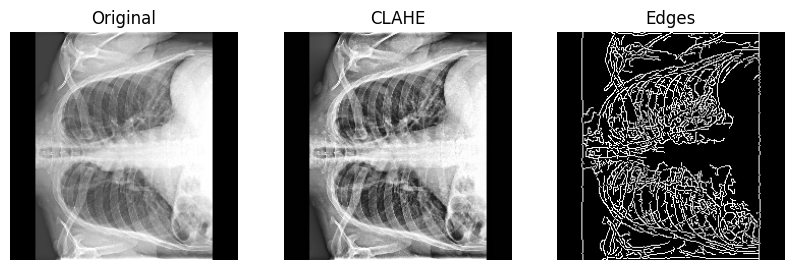

Predicció: NÒDUL  (confiança: 0.9955)


In [ ]:
show_multicanal("/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0175.mha")
